# 02 - Baseline Industry Portfolios

Construct naive equal-weighted (EW) and value-weighted (VW) industry portfolios as benchmarks.
Compute performance metrics, correlation heatmaps, and compare against MSCI EM.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

from src.data_loader import (
    load_signal_data, load_benchmark, INDUSTRIES,
    RETURN_COL_PORTFOLIO, FACTOR_NAMES
)
from src.performance import (
    performance_table, plot_cumulative_returns,
    plot_correlation_heatmap, plot_drawdown
)

DATA_DIR = '../data'
OUTPUT_DIR = '../output'

In [2]:
df = load_signal_data(DATA_DIR)
benchmark = load_benchmark(DATA_DIR)
df_valid = df.dropna(subset=['industry'])

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03


Benchmark loaded: 289 months | 2001-05 to 2025-05


## 1. Equal-Weighted Industry Portfolios

For each industry-month, compute the simple average of all stock returns.

In [3]:
ew_industry = df_valid.groupby(['ym', 'industry'])[RETURN_COL_PORTFOLIO].mean().unstack()
ew_industry = ew_industry[INDUSTRIES].dropna(how='all')

ew_master = ew_industry.mean(axis=1)
ew_master.name = 'EW All Industries'

print(f'EW industry returns: {ew_industry.shape}')
print(f'Date range: {ew_industry.index.min():%Y-%m} to {ew_industry.index.max():%Y-%m}')

EW industry returns: (255, 11)
Date range: 2004-01 to 2025-03


## 2. Value-Weighted Industry Portfolios

Weight each stock by its market cap within each industry-month.

In [4]:
def vw_return(group):
    valid = group.dropna(subset=[RETURN_COL_PORTFOLIO, 'mktcap_m'])
    if valid.empty or valid['mktcap_m'].sum() == 0:
        return np.nan
    weights = valid['mktcap_m'] / valid['mktcap_m'].sum()
    return (weights * valid[RETURN_COL_PORTFOLIO]).sum()

vw_industry = df_valid.groupby(['ym', 'industry']).apply(vw_return, include_groups=False).unstack()
vw_industry = vw_industry[INDUSTRIES].dropna(how='all')

vw_master = vw_industry.mean(axis=1)
vw_master.name = 'VW All Industries'

print(f'VW industry returns: {vw_industry.shape}')

VW industry returns: (255, 11)


## 3. Performance Comparison

In [5]:
common_dates = ew_industry.index.intersection(benchmark.index)
bench_aligned = benchmark.loc[common_dates]

returns_dict = {
    'MSCI EM': bench_aligned,
    'EW All Industries': ew_master.loc[common_dates],
    'VW All Industries': vw_master.loc[common_dates],
}

perf = performance_table(returns_dict)
print(perf.round(4).to_string())

                   Ann. Mean  Ann. Std  Sharpe  IR  Max DD  Calmar  % Positive  Total Return  N Months
Strategy                                                                                              
MSCI EM               0.0647    0.2031  0.3187 NaN  0.6267  0.1033      0.5647        1.5311       255
EW All Industries     0.1126    0.2015  0.5586 NaN  0.5528  0.2036      0.5882        6.0332       255
VW All Industries     0.1217    0.2129  0.5716 NaN  0.5993  0.2030      0.5882        7.1027       255


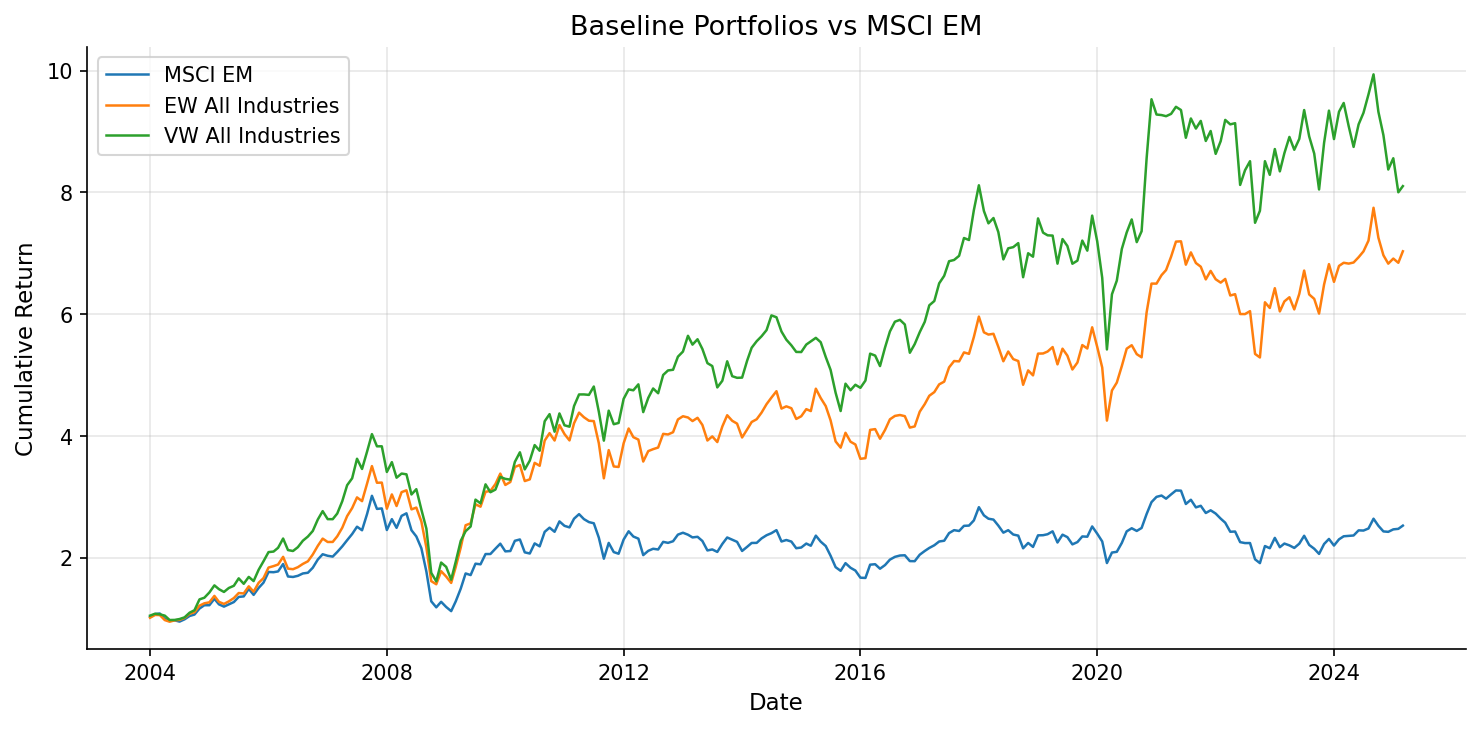

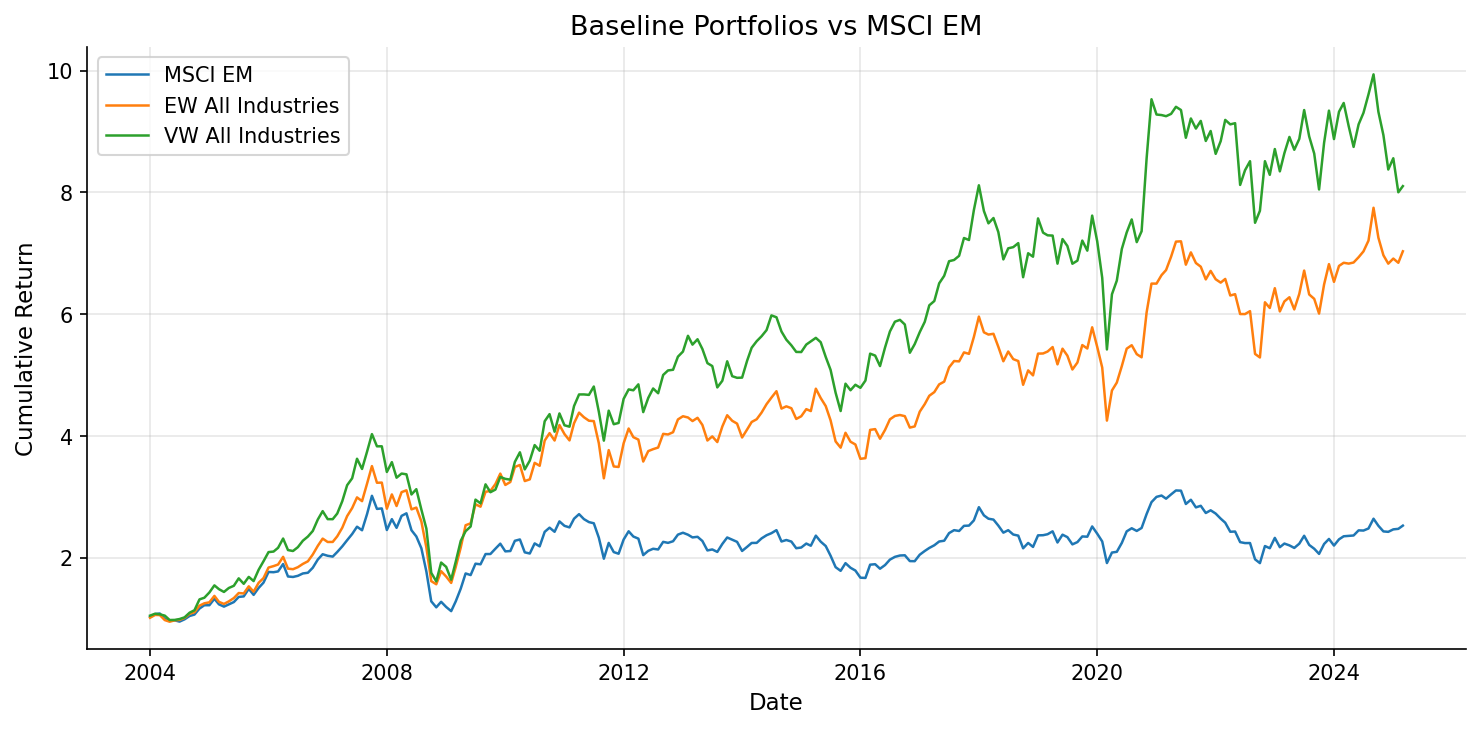

In [6]:
plot_cumulative_returns(
    returns_dict,
    title='Baseline Portfolios vs MSCI EM',
    save_path=f'{OUTPUT_DIR}/figures/baseline_cumulative.pdf'
)

## 4. Individual Industry Performance (EW)

In [7]:
ind_returns = {ind: ew_industry[ind].dropna() for ind in INDUSTRIES}
ind_perf = performance_table(ind_returns)
print(ind_perf.round(4).to_string())

          Ann. Mean  Ann. Std  Sharpe  IR  Max DD  Calmar  % Positive  Total Return  N Months
Strategy                                                                                     
BMATR        0.1232    0.2711  0.4546 NaN  0.6549  0.1882      0.5333        5.1653       255
CODIS        0.1020    0.2310  0.4417 NaN  0.6271  0.1627      0.5922        3.9310       255
COSTP        0.1141    0.1648  0.6922 NaN  0.3769  0.3027      0.5882        7.3948       255
ENEGY        0.1193    0.2548  0.4683 NaN  0.6020  0.1982      0.5882        5.2558       255
FINAN        0.1255    0.2242  0.5598 NaN  0.6214  0.2020      0.5725        7.3067       255
HLTHC        0.1106    0.2247  0.4923 NaN  0.4853  0.2279      0.5647        5.1565       255
INDUS        0.1101    0.2405  0.4576 NaN  0.6679  0.1648      0.5647        4.5146       255
RLEST        0.1323    0.3225  0.4103 NaN  0.7681  0.1723      0.5451        4.6090       255
TECNO        0.1078    0.2332  0.4622 NaN  0.6474  0.1665   

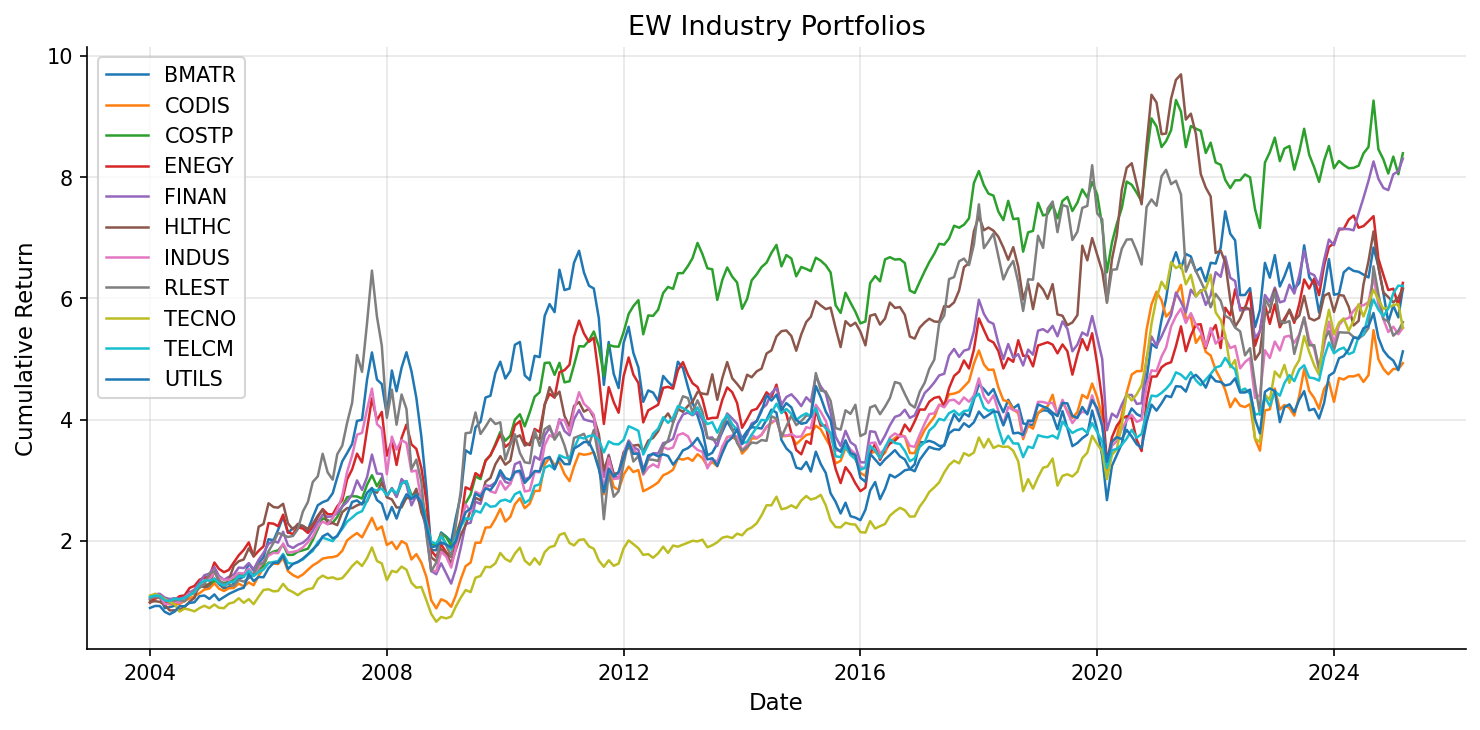

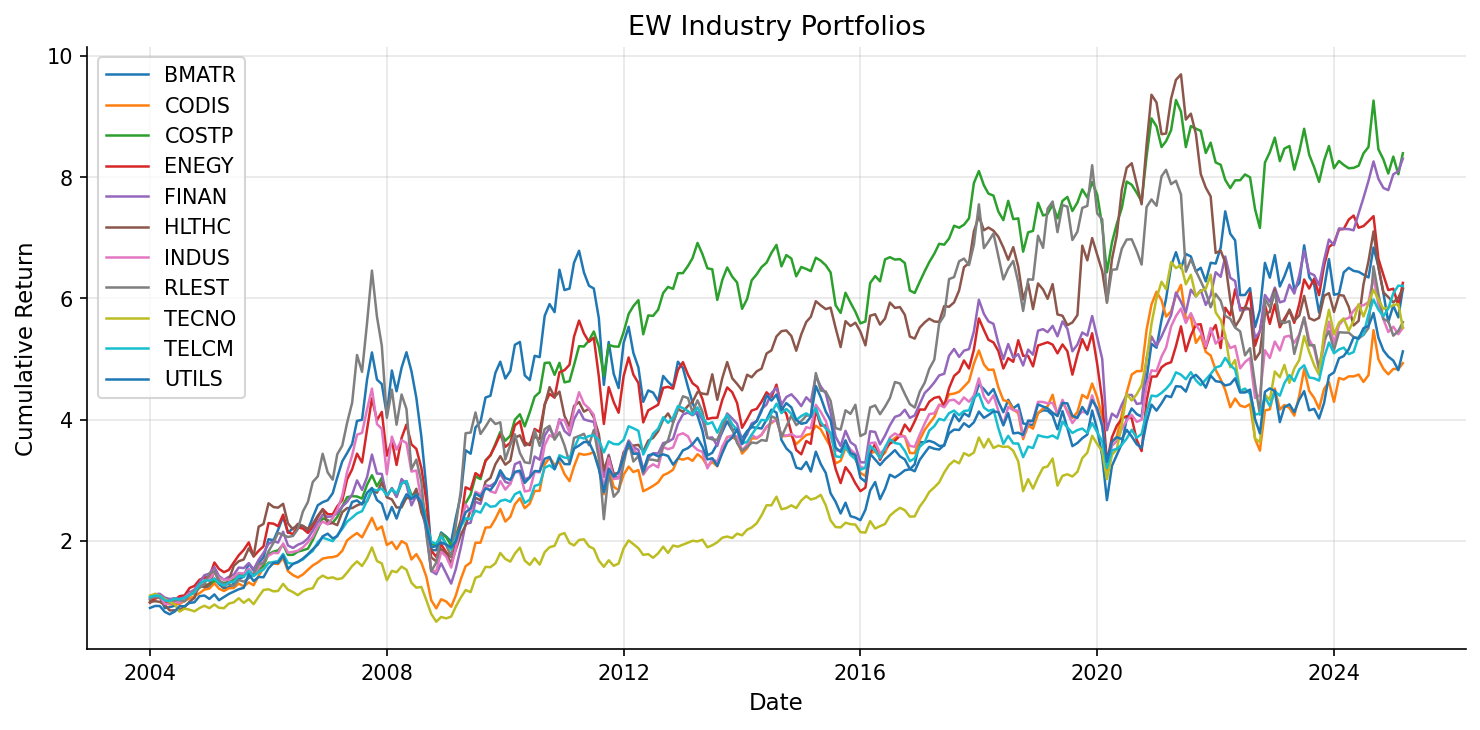

In [8]:
plot_cumulative_returns(
    ind_returns,
    title='EW Industry Portfolios',
    save_path=f'{OUTPUT_DIR}/figures/ew_industry_cumulative.pdf'
)

## 5. Correlation Heatmap

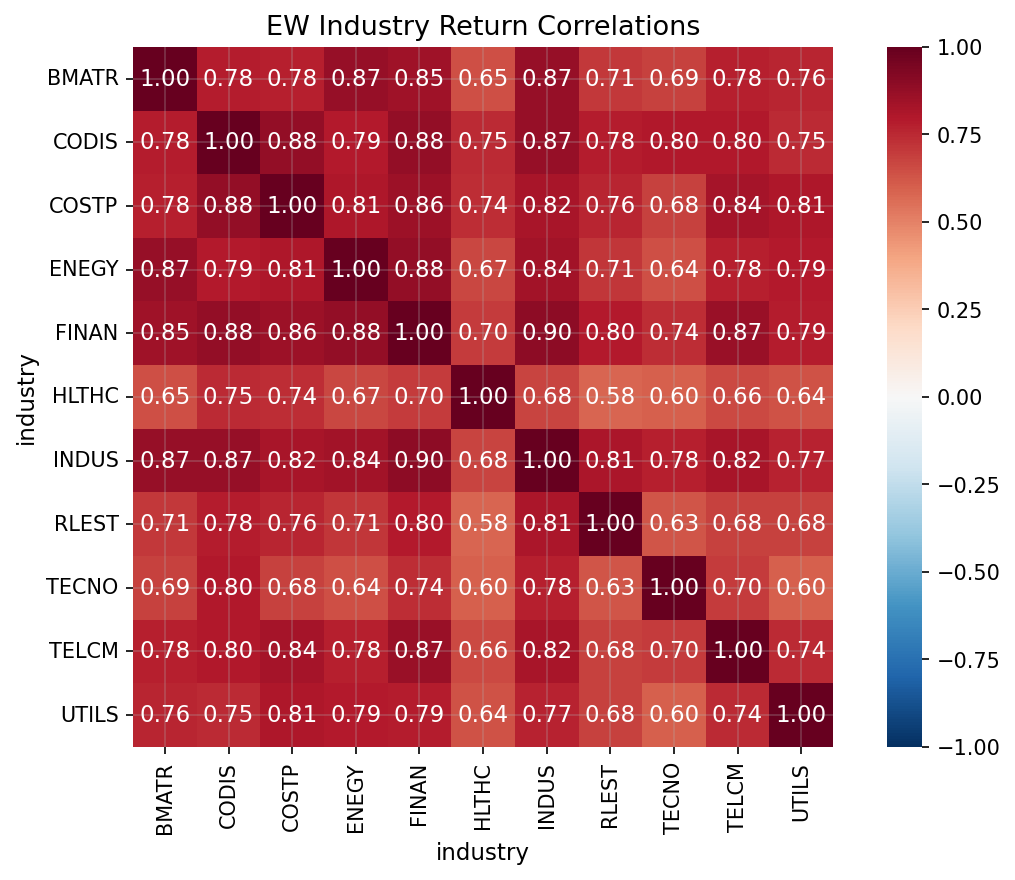

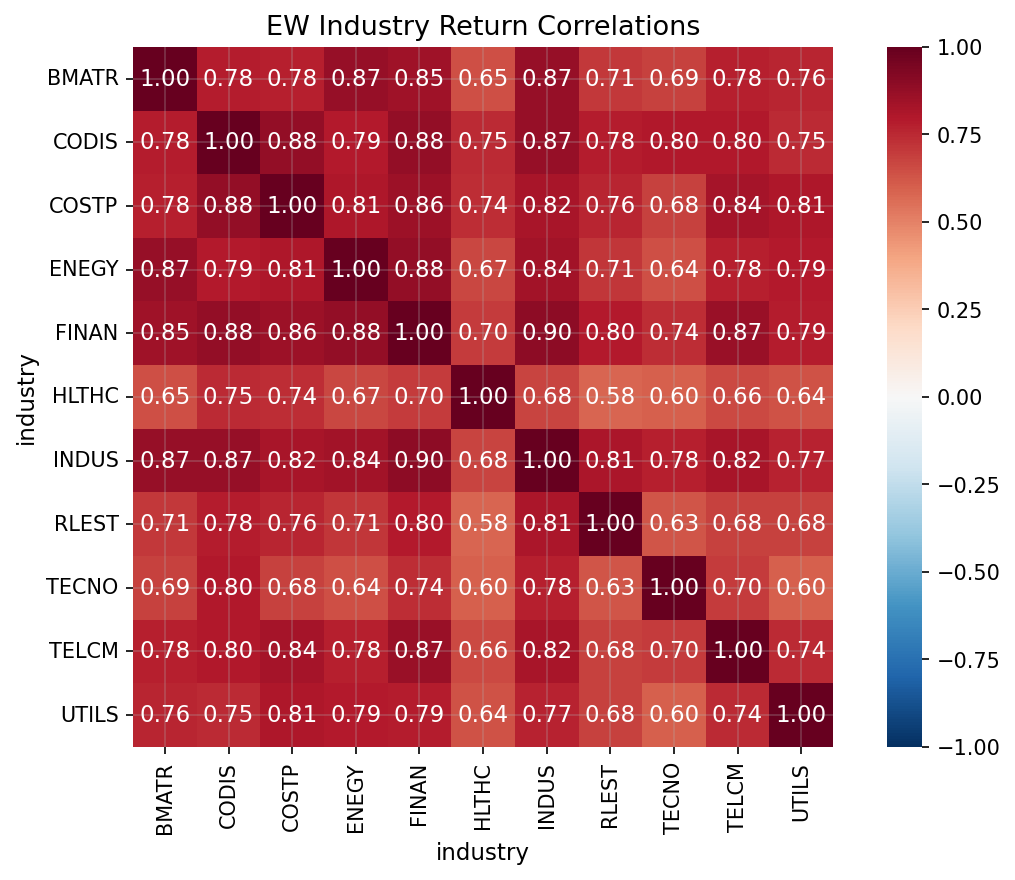

In [9]:
plot_correlation_heatmap(
    ew_industry[INDUSTRIES],
    title='EW Industry Return Correlations',
    save_path=f'{OUTPUT_DIR}/figures/ew_industry_correlation.pdf'
)

## 6. Drawdowns

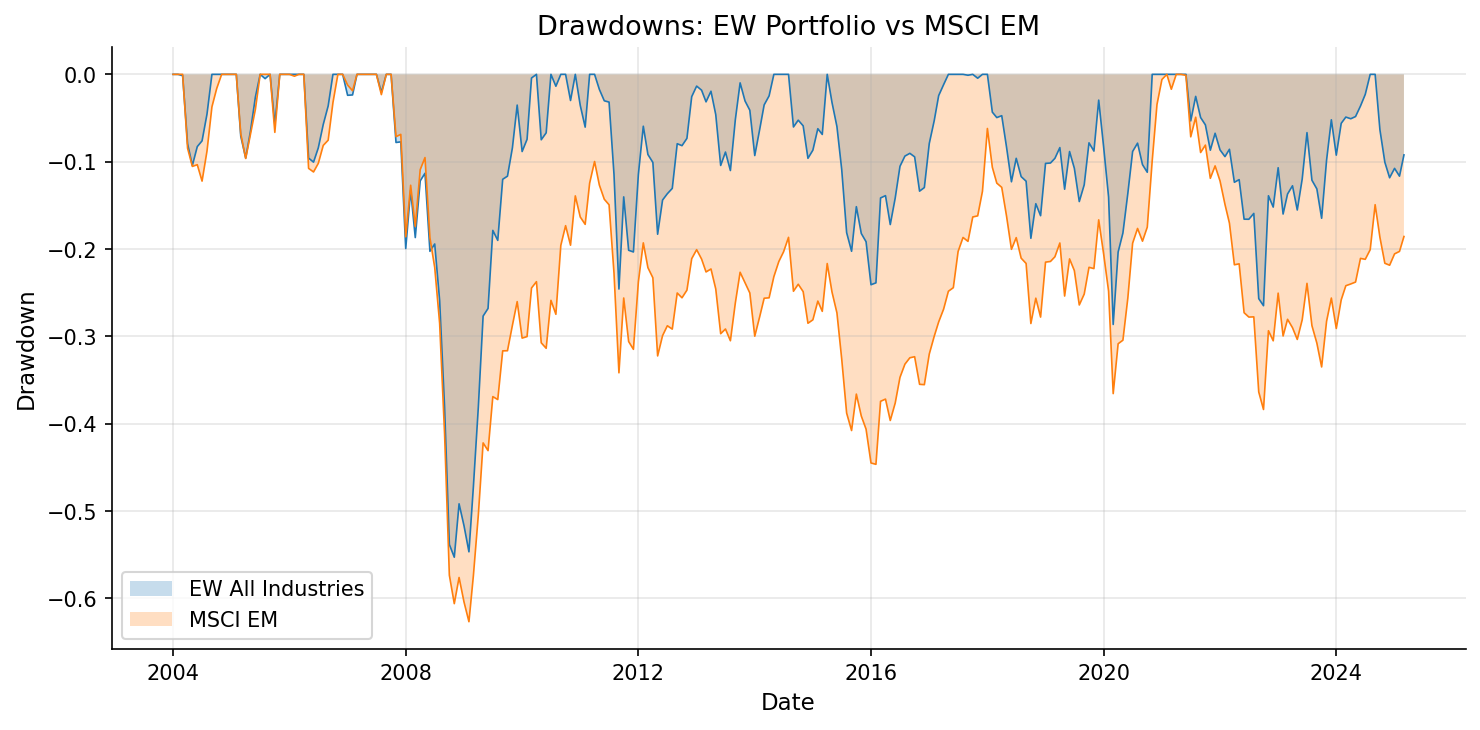

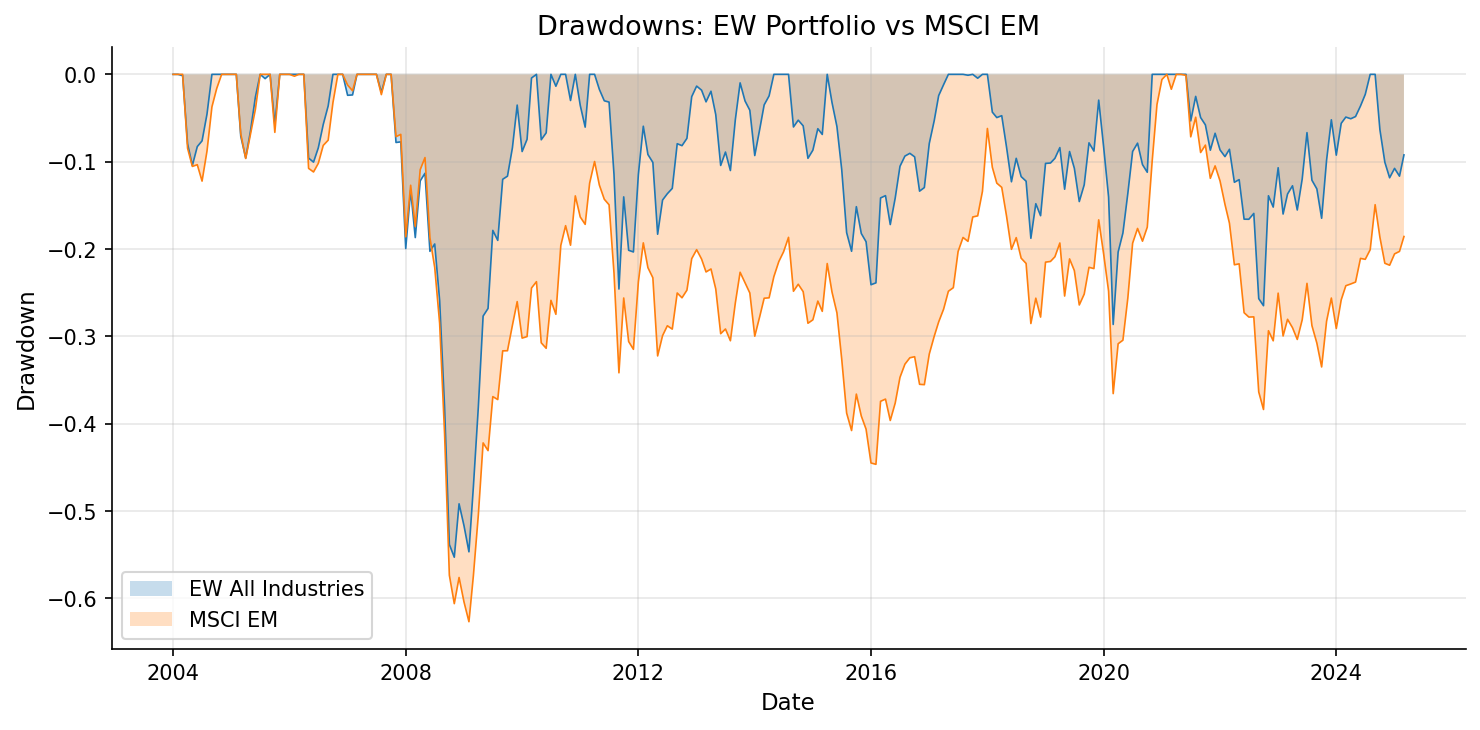

In [10]:
plot_drawdown(
    {'EW All Industries': ew_master.loc[common_dates],
     'MSCI EM': bench_aligned},
    title='Drawdowns: EW Portfolio vs MSCI EM',
    save_path=f'{OUTPUT_DIR}/figures/baseline_drawdown.pdf'
)

## 7. Save Baseline Returns

In [11]:
ew_industry.to_csv(f'{OUTPUT_DIR}/csv/ew_industry_returns.csv')
vw_industry.to_csv(f'{OUTPUT_DIR}/csv/vw_industry_returns.csv')
perf.to_csv(f'{OUTPUT_DIR}/csv/baseline_performance.csv')
ind_perf.to_csv(f'{OUTPUT_DIR}/csv/ew_industry_performance.csv')
print('Baseline results saved.')

Baseline results saved.


## Industry Correlation Heatmap


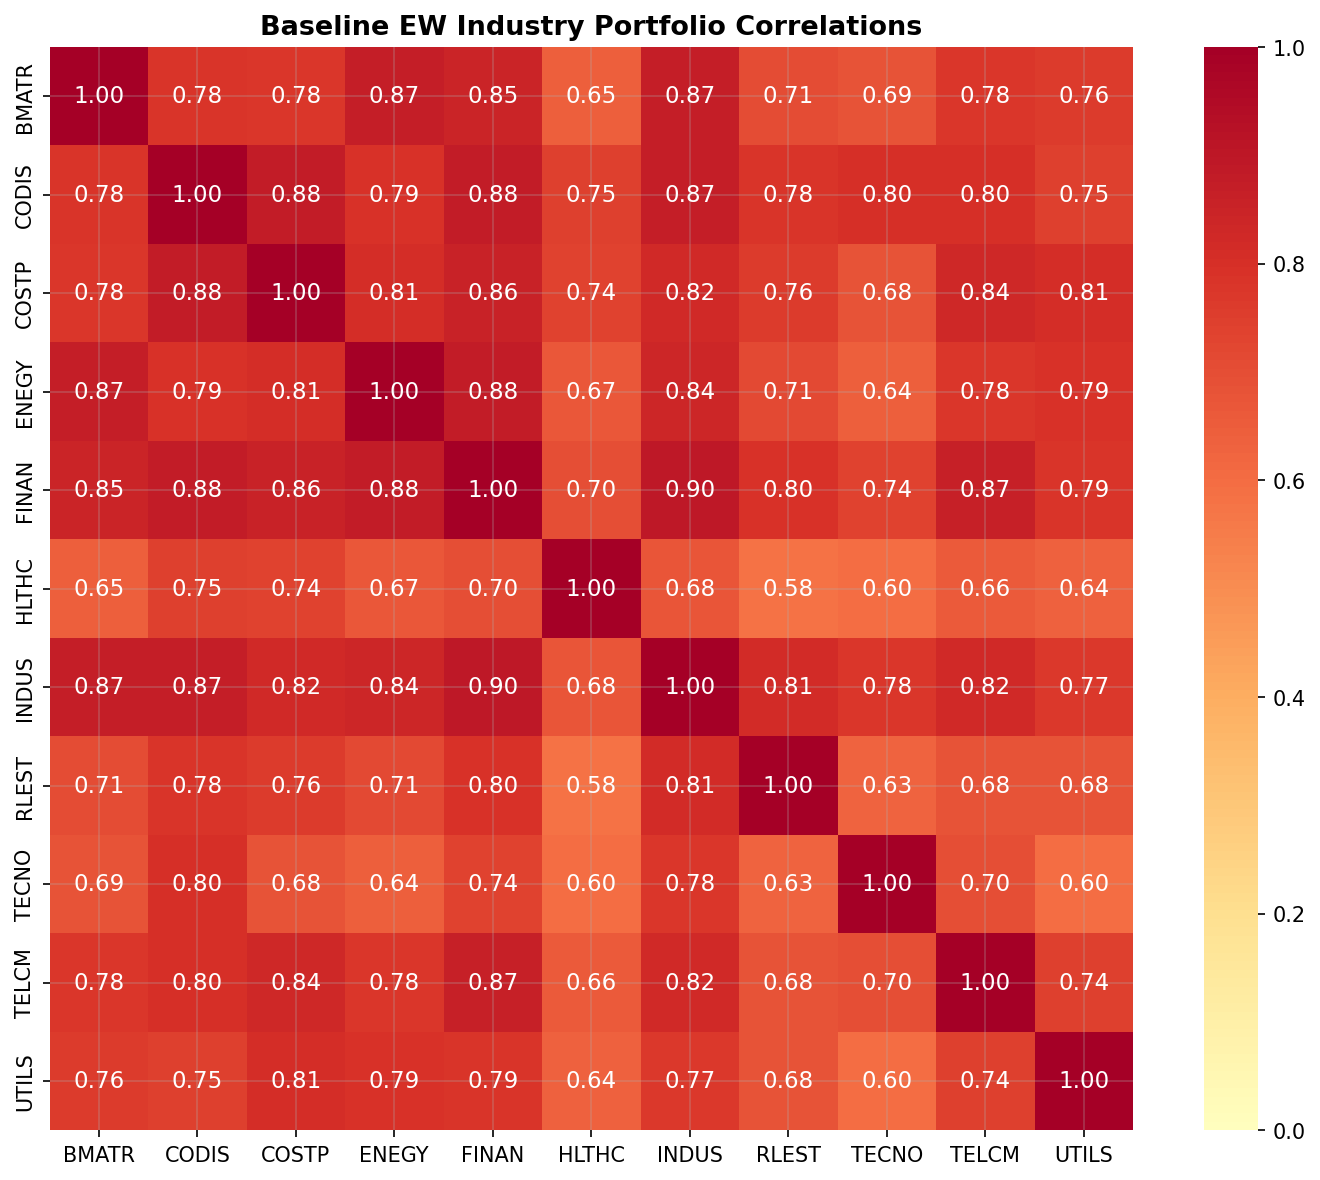

Average pairwise correlation: 0.761


In [12]:
import seaborn as sns
# Compute pairwise correlation of EW industry returns
ew_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/ew_industry_returns.csv', index_col=0, parse_dates=True)
corr = ew_ret.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            vmin=0, vmax=1, square=True, ax=ax)
ax.set_title('Baseline EW Industry Portfolio Correlations', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/ew_industry_correlation.pdf', bbox_inches='tight')
plt.show()
print(f'Average pairwise correlation: {corr.values[np.triu_indices(len(corr),1)].mean():.3f}')
